# Netflix Data Analysis 
This project explores the Netflix Movies and TV Shows dataset using Python.   
The goal is to analyze trends in content type, genres, and release years using data analysis and visualization techniques.  
Tools used: 
- Python 
- Pandas 
- NumPy 
- Matplotlib 
- Seaborn

In [1]:
# importing lib.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_movies (1).csv', lineterminator='\n')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description\r
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# viewing dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
  8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
# exploring genres column
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [5]:
# check for duplicated rows
df.duplicated().sum()

0

In [6]:
# exploring summary statistics
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Exploratory Data Analysis Summary
we have a dataframe consisting of 8807 rows and 12 columns.
Our dataset looks a bit tidy with no NaNs nor duplicated values.
date_added column needs to be casted into the date time and to extract only the year value.
description\r, duration and date_added wouldn't be so useful during analysis, so we'll drop them.
listed_in column has comma saperated values and white spaces that needs to be handled and casted into category. Exploration Summary 

Dropping the columns

In [7]:
cols = ['description\r','duration' ,'date_added']

In [8]:
df.drop(cols,axis =1,inplace = True)
df.columns 

Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'release_year', 'rating', 'listed_in'],
      dtype='object')

In [9]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2020,PG-13,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021,TV-MA,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ..."


In [11]:
df.dropna(inplace = True)
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_year    0
rating          0
listed_in       0
dtype: int64

In [12]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,"Dramas, Independent Movies, International Movies"
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,"British TV Shows, Reality TV"
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,TV-MA,"Dramas, International Movies"
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,1998,TV-14,"Comedies, International Movies, Romantic Movies"


handling missing values

In [13]:
df['listed_in'] = df['listed_in'].fillna('Unknown') 

In [14]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,"Dramas, Independent Movies, International Movies"
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,"British TV Shows, Reality TV"
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,TV-MA,"Dramas, International Movies"
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,1998,TV-14,"Comedies, International Movies, Romantic Movies"


Split genres

In [15]:
df['listed_in'] = df['listed_in'].str.split(', ')

Explode

In [16]:
df = df.explode('listed_in').reset_index(drop=True)

In [17]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in
0,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,Dramas
1,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,Independent Movies
2,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,International Movies
3,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,British TV Shows
4,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,Reality TV


In [18]:
#casting column into category 
df['listed_in'] = df['listed_in'].astype('category')
df['listed_in'].dtypes

CategoricalDtype(categories=['Action & Adventure', 'Anime Features', 'Anime Series',
                  'British TV Shows', 'Children & Family Movies',
                  'Classic & Cult TV', 'Classic Movies', 'Comedies',
                  'Crime TV Shows', 'Cult Movies', 'Documentaries',
                  'Docuseries', 'Dramas', 'Faith & Spirituality',
                  'Horror Movies', 'Independent Movies',
                  'International Movies', 'International TV Shows', 'Kids' TV',
                  'Korean TV Shows', 'LGBTQ Movies', 'Movies',
                  'Music & Musicals', 'Reality TV', 'Romantic Movies',
                  'Romantic TV Shows', 'Sci-Fi & Fantasy',
                  'Science & Nature TV', 'Spanish-Language TV Shows',
                  'Sports Movies', 'Stand-Up Comedy',
                  'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure',
                  'TV Comedies', 'TV Dramas', 'TV Horror', 'TV Mysteries',
                  'TV Sci-Fi & Fantasy', '

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11861 entries, 0 to 11860
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       11861 non-null  object  
 1   type          11861 non-null  object  
 2   title         11861 non-null  object  
 3   director      11861 non-null  object  
 4   cast          11861 non-null  object  
 5   country       11861 non-null  object  
 6   release_year  11861 non-null  int64   
 7   rating        11861 non-null  object  
 8   listed_in     11861 non-null  category
dtypes: category(1), int64(1), object(7)
memory usage: 754.4+ KB


In [20]:
df.nunique()

show_id         5335
type               2
title           5333
director        3946
cast            5201
country          604
release_year      72
rating            17
listed_in         42
dtype: int64

In [21]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in
0,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,Dramas
1,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,Independent Movies
2,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,International Movies
3,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,British TV Shows
4,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,Reality TV


Data Visualization

In [22]:
sns.set_style('whitegrid')

What is the most frequent genre of movies released on netflix?

In [23]:
df['listed_in'].describe()

count                    11861
unique                      42
top       International Movies
freq                      2369
Name: listed_in, dtype: object

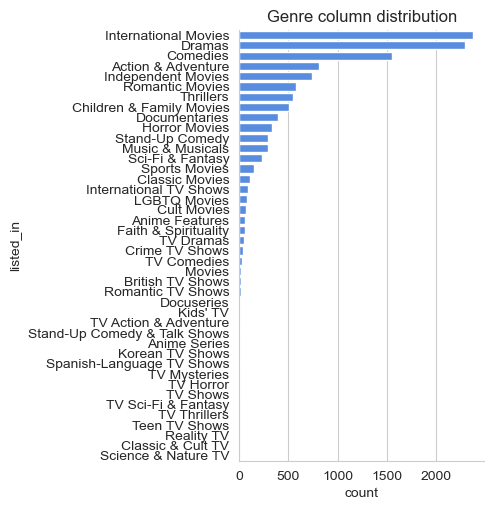

In [28]:
sns.catplot(y ='listed_in', data = df, kind = 'count',
            order = df['listed_in'].value_counts().index,
            color = '#4287f5')
plt.title('Genre column distribution')
plt.show()

Which year has the most filmmed movies?

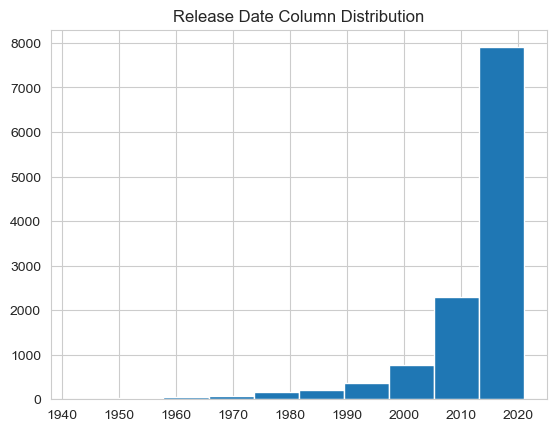

In [30]:
df['release_year'].hist()
plt.title('Release Date Column Distribution')
plt.show()